In [1]:
import torch
from diffusers import FluxPipeline

pipe = FluxPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-dev",
    torch_dtype=torch.bfloat16,
)
pipe.to('cuda')

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

FluxPipeline {
  "_class_name": "FluxPipeline",
  "_diffusers_version": "0.37.1",
  "_name_or_path": "black-forest-labs/FLUX.1-dev",
  "feature_extractor": [
    null,
    null
  ],
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "T5EncoderModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "T5Tokenizer"
  ],
  "transformer": [
    "diffusers",
    "FluxTransformer2DModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

# FLUX.1 Pipeline — Interface Points

FLUX.1 is a **flow matching** model (not DDPM). It learns a continuous vector field mapping noise → image.

## Components

### 1. Text Encoders (dual)
- **CLIP-L** (`pipe.text_encoder`, `pipe.tokenizer`) — 77-token limit, semantic
- **T5-XXL** (`pipe.text_encoder_2`, `pipe.tokenizer_2`) — 512-token limit, long-form

Interface: swap encoders, intercept/modify embeddings, prompt mixing via embedding arithmetic.

### 2. VAE (`pipe.vae`)
Encodes images into latents (8x compression) and decodes back to pixels.
- `pipe.vae.encode(image)` → latent
- `pipe.vae.decode(latent)` → image

Interface: img2img, decode intermediate latents, swap fine-tuned VAE.

### 3. Transformer — MMDiT (`pipe.transformer`)
The core model. Jointly attends over image patches and text tokens.
- Double-stream blocks → separate image/text streams
- Single-stream blocks → fused attention

Interface: LoRA weights, register_forward_hook on blocks, ControlNet, guidance.

### 4. Scheduler (`pipe.scheduler`)
Flow matching scheduler: `FlowMatchEulerDiscreteScheduler`.
Controls noise trajectory and timestep schedule.

Interface: swap schedulers, modify timesteps, adjust `guidance_scale`.

### 5. Full forward pass order
```
prompt
  → tokenize (CLIP + T5)
  → encode text → (clip_embeds, t5_embeds, pooled_embeds)
  → initialize latent noise
  → for t in timesteps:
        transformer(latent, text_embeds, t) → predicted velocity
        scheduler.step() → denoised latent
  → VAE decode → pixel image
```

## 1. Text Encoders

In [2]:
prompt = "a photo of a cat sitting on a table"

# --- CLIP-L encoder (short semantic, 77-token max) ---
clip_tokens = pipe.tokenizer(
    prompt,
    return_tensors="pt",
    padding="max_length",
    max_length=77,
    truncation=True,
).to(pipe.device)

with torch.no_grad():
    clip_embeds = pipe.text_encoder(**clip_tokens)
    pooled_clip = clip_embeds.pooler_output       # (1, 768)  — used as conditioning
    clip_seq    = clip_embeds.last_hidden_state   # (1, 77, 768)

print("CLIP pooled:", pooled_clip.shape)
print("CLIP seq:   ", clip_seq.shape)

# --- T5-XXL encoder (long-form, up to 512 tokens) ---
t5_tokens = pipe.tokenizer_2(
    prompt,
    return_tensors="pt",
    padding="max_length",
    max_length=512,
    truncation=True,
).to(pipe.device)

with torch.no_grad():
    t5_embeds = pipe.text_encoder_2(**t5_tokens).last_hidden_state  # (1, 512, 4096)

print("T5 seq:     ", t5_embeds.shape)

CLIP pooled: torch.Size([1, 768])
CLIP seq:    torch.Size([1, 77, 768])
T5 seq:      torch.Size([1, 512, 4096])


## 2. VAE — Encode & Decode

Latent shape: torch.Size([1, 16, 128, 128])


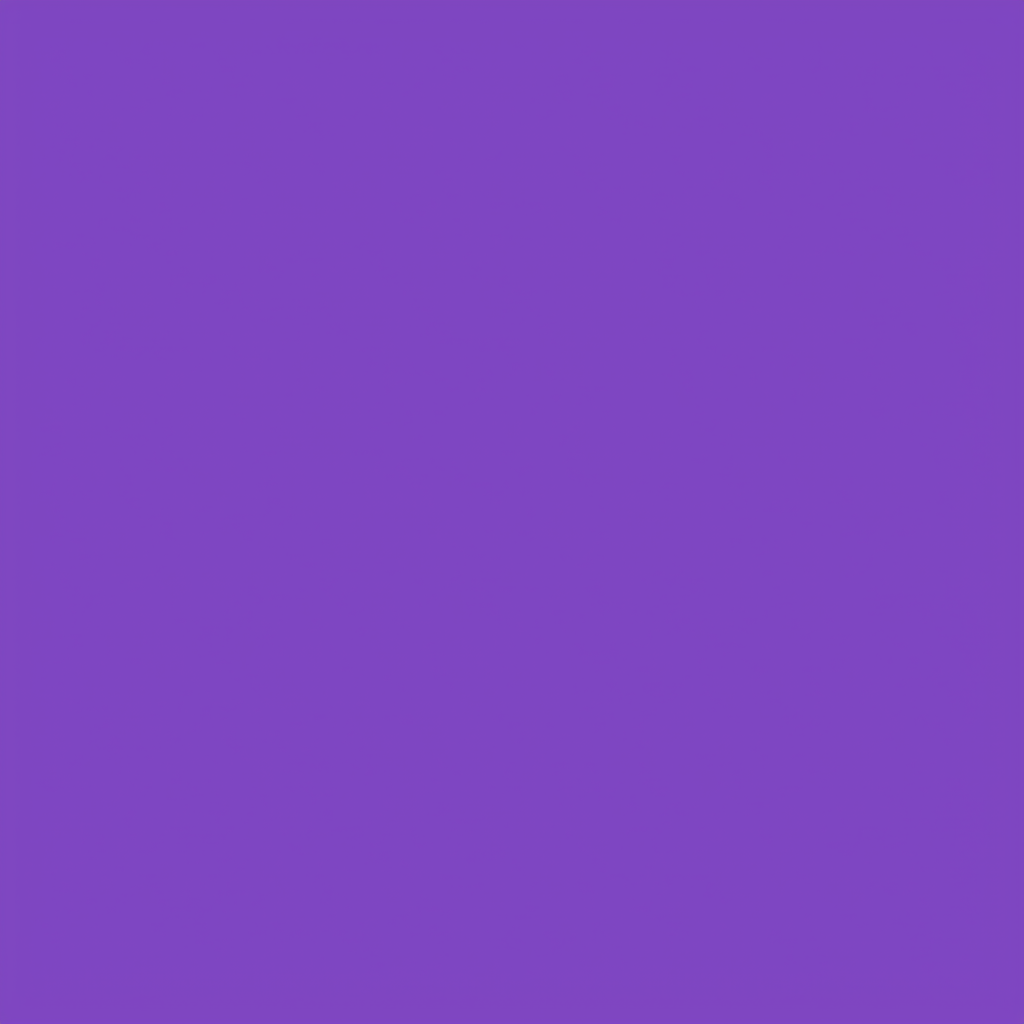

In [3]:
from PIL import Image
import torchvision.transforms as T

# Load any image and encode it into latent space
def encode_image(pipe, pil_image):
    transform = T.Compose([
        T.ToTensor(),
        T.Normalize([0.5], [0.5]),  # [-1, 1]
    ])
    x = transform(pil_image).unsqueeze(0).to(pipe.vae.device, dtype=pipe.vae.dtype)
    with torch.no_grad():
        latent = pipe.vae.encode(x).latent_dist.sample()
        latent = (latent - pipe.vae.config.shift_factor) * pipe.vae.config.scaling_factor
    return latent  # shape: (1, 16, H/8, W/8)

def decode_latent(pipe, latent):
    latent = latent / pipe.vae.config.scaling_factor + pipe.vae.config.shift_factor
    with torch.no_grad():
        image = pipe.vae.decode(latent).sample
    image = (image / 2 + 0.5).clamp(0, 1)
    return T.ToPILImage()(image[0].cpu().float())

# Example: round-trip encode/decode a blank image
dummy = Image.new("RGB", (1024, 1024), color=(128, 64, 200))
latent = encode_image(pipe, dummy)
print("Latent shape:", latent.shape)  # (1, 16, 128, 128)

reconstructed = decode_latent(pipe, latent)
reconstructed

## 3. Transformer (MMDiT) — Hook into Blocks

Double-stream blocks: 19
Single-stream blocks: 38



  0%|          | 0/20 [00:00<?, ?it/s]

Captured img hidden shape: torch.Size([1, 512, 3072])
Captured txt hidden shape: torch.Size([1, 1024, 3072])


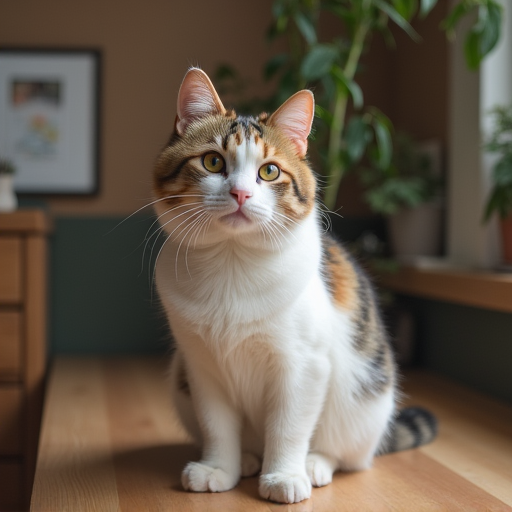

In [4]:
# Inspect transformer structure
print("Double-stream blocks:", len(pipe.transformer.transformer_blocks))
print("Single-stream blocks:", len(pipe.transformer.single_transformer_blocks))
print()

# Example: register a forward hook on the last double-stream block
# to capture the hidden states (image + text tokens fused)
captured = {}

def hook_fn(module, input, output):
    # output is a tuple: (img_hidden, txt_hidden) for double-stream blocks
    captured["last_double_block_img"] = output[0].detach().cpu()
    captured["last_double_block_txt"] = output[1].detach().cpu()

hook = pipe.transformer.transformer_blocks[-1].register_forward_hook(hook_fn)

# Run generation — hook fires during the transformer forward pass
image = pipe(
    prompt,
    height=512,
    width=512,
    guidance_scale=3.5,
    num_inference_steps=20,   # low for speed during debugging
    max_sequence_length=512,
    generator=torch.Generator("cpu").manual_seed(0),
).images[0]

hook.remove()

print("Captured img hidden shape:", captured["last_double_block_img"].shape)
print("Captured txt hidden shape:", captured["last_double_block_txt"].shape)
image

## 4. Scheduler — Custom Timesteps

In [6]:
from diffusers.pipelines.flux.pipeline_flux import calculate_shift

print(type(pipe.scheduler).__name__)
print("Config:", pipe.scheduler.config)

# FLUX.1-dev uses dynamic shifting — mu is computed from image sequence length
# mu controls how much the timestep schedule is shifted based on resolution
height, width = 512, 512
image_seq_len = (height // 8 // 2) * (width // 8 // 2)  # number of latent patches
mu = calculate_shift(
    image_seq_len,
    pipe.scheduler.config.base_image_seq_len,
    pipe.scheduler.config.max_image_seq_len,
    pipe.scheduler.config.base_shift,
    pipe.scheduler.config.max_shift,
)
print(f"\nmu for {height}x{width} image (seq_len={image_seq_len}): {mu:.4f}")

pipe.scheduler.set_timesteps(num_inference_steps=20, mu=mu, device=pipe.device)
print("\nTimesteps (20 steps):")
print(pipe.scheduler.timesteps)
# Timesteps go from ~1.0 (pure noise) → 0.0 (clean image) in flow matching

FlowMatchEulerDiscreteScheduler
Config: FrozenDict({'num_train_timesteps': 1000, 'shift': 3.0, 'use_dynamic_shifting': True, 'base_shift': 0.5, 'max_shift': 1.15, 'base_image_seq_len': 256, 'max_image_seq_len': 4096, 'invert_sigmas': False, 'shift_terminal': None, 'use_karras_sigmas': False, 'use_exponential_sigmas': False, 'use_beta_sigmas': False, 'time_shift_type': 'exponential', 'stochastic_sampling': False, '_use_default_values': ['shift_terminal', 'use_karras_sigmas', 'stochastic_sampling', 'invert_sigmas', 'time_shift_type', 'use_beta_sigmas', 'use_exponential_sigmas'], '_class_name': 'FlowMatchEulerDiscreteScheduler', '_diffusers_version': '0.30.0.dev0'})

mu for 512x512 image (seq_len=1024): 0.6300

Timesteps (20 steps):
tensor([1000.0000,  971.2914,  941.0987,  909.3038,  875.7759,  840.3691,
         802.9210,  763.2499,  721.1517,  676.3965,  628.7249,  577.8420,
         523.4120,  465.0508,  402.3164,  334.6980,  261.6024,  182.3358,
          96.0825,    1.8760], device=

## 5. Full Manual Forward Pass

Initial latent shape:      torch.Size([1, 1024, 64])
latent_image_ids shape:    torch.Size([1024, 3])


100%|██████████| 20/20 [00:06<00:00,  2.97it/s]


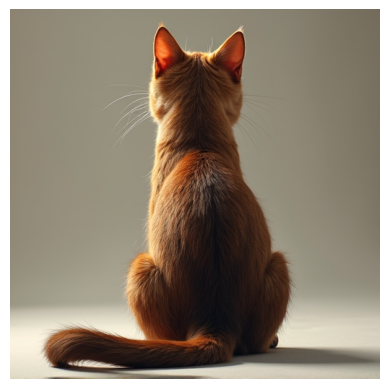

In [13]:
# Full manual pipeline — every step explicit and replaceable
from diffusers.pipelines.flux.pipeline_flux import retrieve_timesteps, calculate_shift
import matplotlib.pyplot as plt
from tqdm import tqdm

prompt = "a back view of a cat"
height, width = 512, 512
num_steps = 20
guidance_scale = 3.5
seed = 0

# 1. Encode text
(
    prompt_embeds,        # T5 embeddings: (1, 512, 4096)
    pooled_prompt_embeds, # CLIP pooled:   (1, 768)
    text_ids,             # T5 token position ids: (512, 3)
) = pipe.encode_prompt(
    prompt=prompt,
    prompt_2=None,
    device=pipe.device,
    num_images_per_prompt=1,
    max_sequence_length=512,
)

# 2. Prepare latents — FLUX returns PACKED latents (B, seq_len, C*4)
#    plus latent_image_ids (2D positional ids for the transformer)
latent_channels = pipe.transformer.config.in_channels // 4
latents, latent_image_ids = pipe.prepare_latents(
    batch_size=1,
    num_channels_latents=latent_channels,
    height=height,
    width=width,
    dtype=prompt_embeds.dtype,
    device=pipe.device,
    generator=torch.Generator(pipe.device).manual_seed(seed),
)
print("Initial latent shape:     ", latents.shape)            # (1, seq_len, 64)
print("latent_image_ids shape:   ", latent_image_ids.shape)   # (seq_len, 3)

# 3. Timesteps — compute mu from resolution for dynamic shifting
image_seq_len = latents.shape[1]
mu = calculate_shift(
    image_seq_len,
    pipe.scheduler.config.base_image_seq_len,
    pipe.scheduler.config.max_image_seq_len,
    pipe.scheduler.config.base_shift,
    pipe.scheduler.config.max_shift,
)
timesteps, num_steps = retrieve_timesteps(pipe.scheduler, num_steps, pipe.device, mu=mu)

# FLUX.1-dev uses distilled guidance passed as a tensor into the transformer,
# not classifier-free guidance via uncond/cond split.
guidance = torch.full([1], guidance_scale, device=pipe.device, dtype=prompt_embeds.dtype)

# 4. Denoising loop — modify latents or embeddings here each step
for i, t in tqdm(enumerate(timesteps), total=len(timesteps)):
    t_input = t.expand(latents.shape[0]).to(latents.dtype)

    with torch.no_grad():
        noise_pred = pipe.transformer(
            hidden_states=latents,
            timestep=t_input / 1000,
            guidance=guidance,
            encoder_hidden_states=prompt_embeds,
            pooled_projections=pooled_prompt_embeds,
            txt_ids=text_ids,
            img_ids=latent_image_ids,
            joint_attention_kwargs=None,
            return_dict=False,
        )[0]

    latents = pipe.scheduler.step(noise_pred, t, latents, return_dict=False)[0]

# 5. Unpack latents back to (B, C, H, W) and decode
latents = pipe._unpack_latents(latents, height, width, pipe.vae_scale_factor)
image = decode_latent(pipe, latents)
plt.imshow(image)
plt.axis('off')
plt.show()